In [1]:
import os
import sys

os.environ["CUDA_VISIBLE_DEVICES"] = "0"
sys.path.append('../') 
os.getcwd()

'/home/shiyuqi/ConfSeq/representation_learning'

In [2]:
from rdkit.Chem import rdchem

import random
from demo.ConfSeq import get_ConfSeq_pair_from_mol,get_mol_from_ConfSeq_pair,randomize_mol
import copy
from tqdm import tqdm

from rdkit.Chem import rdmolops, rdchem

from transformers import BartForConditionalGeneration, BartConfig
import torch
from torch import nn
from rdkit import Chem
import copy

/home/shiyuqi/miniconda3/envs/confseq/lib/python3.11/site-packages/torchvision/io/image.py:14: UserWarning: Failed to load image Python extension: '/home/shiyuqi/miniconda3/envs/confseq/lib/python3.11/lib-dynload/../../libz.so.1: version `ZLIB_1.2.9' not found (required by /home/shiyuqi/miniconda3/envs/confseq/lib/python3.11/site-packages/torchvision/../../../libpng16.so.16)'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


In [3]:
from rdkit import Chem
import random
from demo.ConfSeq import randomize_mol,get_TD_smiles_from_mol,get_p_chiral_dic,find_all_equ_atoms,find_part_equ_atoms,get_TD_smiles_in_smiles_iso,add_chiral_to_TD_smiles_in_smiles,get_ConfSeq_pair_from_mol,get_mol_from_ConfSeq_pair,del_add_chiral_from_TD_smiles,get_p_chiral_mol_3d,get_atom_pair_dihedrals_dic_from_TD_SMILES,reset_dihedrals,get_st_dihedrals,get_bond_token_atom_pairs,replace_smiles_BE,condense_t_smiles_lis
import copy
from tqdm import tqdm
from tqdm.contrib.concurrent import process_map  

from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

from transformers import BartForConditionalGeneration, BartConfig
from collections import OrderedDict
import torch
from torch import nn

import numpy as np
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

In [4]:
def rm_invalid_chirality(mol):
    mol = copy.deepcopy(mol)
    """
    找出分子中同时出现在三个环中的原子。
    
    参数:
        mol: RDKit 分子对象
    返回:
        List[int]: 同时出现在三个环中的原子的索引列表
    """
    # 获取分子的所有环（SSSR：最小集的简单环）
    rings = rdmolops.GetSymmSSSR(mol)

    # 创建一个字典，记录每个原子出现在多少个环中
    atom_in_rings_count = {}

    # 遍历所有环，统计每个原子出现的次数
    for ring in rings:
        for atom_idx in ring:
            if atom_idx not in atom_in_rings_count:
                atom_in_rings_count[atom_idx] = 0
            atom_in_rings_count[atom_idx] += 1

    # 找出那些同时出现在三个环中的原子
    atoms_in_3_rings = [atom for atom, count in atom_in_rings_count.items() if count == 3]

    for atom_idx in atoms_in_3_rings:
        atom = mol.GetAtomWithIdx(atom_idx)
        atom.SetChiralTag(rdchem.ChiralType.CHI_UNSPECIFIED)

    return mol


def neutralize_charge(mol):
    """
    检查分子中是否有带电荷的原子。如果有，且该原子没有邻居原子带相反电荷，
    则将该原子的电荷设为 0，并调整相应的氢的数目。

    参数:
        mol (rdkit.Chem.Mol): 输入的分子对象。

    返回:
        rdkit.Chem.Mol: 经过处理的分子对象。
    """
    # 检查每个原子的电荷
    for atom in mol.GetAtoms():
        charge = atom.GetFormalCharge()
        num_h = atom.GetNumExplicitHs()

        # 条件: 原子负电荷，或原子正电荷且其氢数目多于电荷数
        if charge < 0 or (charge > 0 and num_h >= charge):
        #if charge != 0:  # 如果原子带电荷
            has_opposite_neighbor = False

            # 检查邻居是否有带相反电荷的原子
            for neighbor in atom.GetNeighbors():
                neighbor_charge = neighbor.GetFormalCharge()
                if neighbor_charge == -charge:
                    has_opposite_neighbor = True
                    break

            if not has_opposite_neighbor:  # 如果没有邻居带相反电荷
                # 将原子电荷设为 0
                atom.SetFormalCharge(0)
                #print(atom.GetNumExplicitHs())
                # 调整氢原子的数目
                if charge > 0:
                    # 原子原本带正电荷，需要增加相应数量的氢
                    atom.SetNumExplicitHs(atom.GetNumExplicitHs() - charge)
                elif charge < 0:
                    # 原子原本带负电荷，需要减少相应数量的氢
                    atom.SetNumExplicitHs(atom.GetNumExplicitHs() - charge)

    # 更新分子状态
    Chem.SanitizeMol(mol)
    return mol

In [5]:
def get_ConfSeq(query_mol):

    if query_mol != None:
        try:
            query_mol = neutralize_charge(query_mol)
            query_mol = rm_invalid_chirality(query_mol)
            query_mol = randomize_mol(query_mol)
            Chem.MolToSmiles(query_mol)    
            query_mol = Chem.RenumberAtoms(query_mol, eval(query_mol.GetProp('_smilesAtomOutputOrder'))) 
            Chem.MolToSmiles(query_mol,canonical = False)
            query_mol = Chem.RenumberAtoms(query_mol, eval(query_mol.GetProp('_smilesAtomOutputOrder'))) 
            in_smiles,TD_smiles = get_ConfSeq_pair_from_mol(query_mol)
            TD_smiles = TD_smiles.replace('<180>','<-180>')
            
        except:
            in_smiles,TD_smiles = '',''            
    else:
        in_smiles,TD_smiles = '',''
        
    return TD_smiles

In [6]:
mol = Chem.MolFromMolFile('./example/3kcf_JZO_C_3.mol')
mol

In [7]:
confseq = get_ConfSeq(mol)
confseq

'C O <111> | <-179> C <109> | <-26> c 1 c c c c ( <47> c 2 c ( <57> c 3 c c c 4 n c c n c 4 c 3 ) n ( C ) n ( C ) c 2 = O ) c 1'

In [8]:
vocab = [chr(i) for i in range(33, 127)] 

for i in range(-180,180):
    vocab.append('<'+str(i)+'>')

vocab.append('<mask>')
vocab.append('<unk>')
vocab.append('<sos>')
vocab.append('<eos>')
vocab.append('<pad>')


config = BartConfig()

config.pad_token_id = vocab.index('<pad>')
config.eos_token_id = vocab.index('<eos>')
config.sos_token_id = vocab.index('<sos>')
config.forced_eos_token_id = None
config.encoder_layers = 6
config.encoder_attention_heads = 8
config.decoder_layers = 0
config.decoder_attention_heads = 0
config.d_model = 256
# config.share_embeddings = True
config.vocab_size = len(vocab)
# config.dropout=0.1        
# config.attention_dropout = 0.1
# config.classifier_dropout = 0.1
# config.num_hidden_layers = 6
# config.static_position_embeddings = True
# ############
# config.max_position_embeddings = 512
# config.activation_function = 'relu'

vocab_dict = {char: idx for idx, char in enumerate(vocab)}
bart = BartForConditionalGeneration(config = config )


class CustomBartEncoder(nn.Module):
    def __init__(self, bart):
        super().__init__()
    
        # 加载 BART 模型
        self.bart_model = bart 
        
    def forward(self, input_ids, attention_mask=None):
        # 获取编码器输出
        outputs = self.bart_model.model.encoder(input_ids=input_ids, attention_mask=attention_mask)
        return outputs.last_hidden_state

# 示例使用
bart_encoder_model  = CustomBartEncoder(bart)
bart_encoder_model.eval()

CustomBartEncoder(
  (bart_model): BartForConditionalGeneration(
    (model): BartModel(
      (shared): BartScaledWordEmbedding(459, 256, padding_idx=458)
      (encoder): BartEncoder(
        (embed_tokens): BartScaledWordEmbedding(459, 256, padding_idx=458)
        (embed_positions): BartLearnedPositionalEmbedding(1026, 256)
        (layers): ModuleList(
          (0-5): 6 x BartEncoderLayer(
            (self_attn): BartAttention(
              (k_proj): Linear(in_features=256, out_features=256, bias=True)
              (v_proj): Linear(in_features=256, out_features=256, bias=True)
              (q_proj): Linear(in_features=256, out_features=256, bias=True)
              (out_proj): Linear(in_features=256, out_features=256, bias=True)
            )
            (self_attn_layer_norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
            (activation_fn): GELUActivation()
            (fc1): Linear(in_features=256, out_features=4096, bias=True)
            (fc2): Linear(in

In [9]:


class TensorDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return torch.Tensor(self.data[idx]).long()

def collate_fn(batch):
    data = batch  # 解压每个样本中的数据和标签
    padded_data = pad_sequence(data, batch_first=True, padding_value = vocab.index('<pad>'))  # 对数据进行填充
    return padded_data


def mean_pooling(last_hidden_state, attention_mask):
    # 对每个样本进行池化，忽略 pad 的位置
    # 将 attention_mask 转换为 float 类型，并进行扩展
    attention_mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size())
    # 计算有效的特征总和和有效特征的数量
    sum_embeddings = (last_hidden_state * attention_mask).sum(dim=1)
    sum_mask = attention_mask.sum(dim=1)
    # 计算平均池化，避免除以零
    pooled_output = sum_embeddings / (sum_mask + 1e-8)  # 加小常数以避免除零
    return pooled_output

In [10]:
def get_embedding_for_seq(model,confseq):
    int = [vocab_dict[i] for i in confseq.split(' ')] 
    int = torch.Tensor([int]).long()
    embed = bart_encoder_model(int).mean(dim=1).tolist()[0]
    return embed

In [ ]:
embedding_pubchem = np.load('./data/pubchem_embeddings/PubChem_embedding.npz')
embedding_pubchem = embedding_pubchem['arr_0']


print(embedding_pubchem.shape)

(97534269, 256)


In [ ]:
# Load the .npy file
pubchem_cid = np.load('./data/pubchem_embeddings/PubChem_CID.npy')

print(pubchem_cid.shape)  # If it's a numpy array

(97534269,)


In [ ]:
checkpoint = torch.load('./checkpoints/model_epoch_1.pth', map_location='cpu')  # 使用适当的设备

new_state_dict = OrderedDict()
for k, v in checkpoint.items():
    if k.startswith('module.'):
        # 去掉前缀 'module.'
        new_state_dict[k[7:]] = v
    else:
        new_state_dict[k] = v

bart_encoder_model.load_state_dict(new_state_dict)

device = torch.device('cuda')

In [13]:
query_embed = get_embedding_for_seq(bart_encoder_model,confseq)

In [14]:
import numpy as np
from tqdm import tqdm

# target 向量 shape: (256,)
# embedding_pubchem shape: (90000000, 256)
  
batch_size = 100000  # 根据内存大小调节批次大小
num_total = embedding_pubchem.shape[0]

dists = np.empty(num_total, dtype=np.float32)  # 存储所有距离

# 分批计算欧氏距离
for start in tqdm(range(0, num_total, batch_size), desc="计算欧氏距离"):
    end = min(start + batch_size, num_total)
    batch = embedding_pubchem[start:end]  # shape: (batch_size, 256)
    dists[start:end] = np.linalg.norm(batch - query_embed, axis=1)



# 获取最近的前 20 个样本索引和距离
topk_indices = np.argsort(dists)[:200]
topk_values = dists[topk_indices]

print("最近的20个样本索引:", topk_indices)
print("对应距离:", topk_values)


for i in topk_indices:
    print(pubchem_cid[i])

计算欧氏距离: 100%|██████████| 976/976 [05:46<00:00,  2.81it/s]


最近的20个样本索引: [43095138 43094997 66783731 43095142 73745054 43095140 43095139 43094665
 43094589 43094662 40838778 40839026 43095141 74641023 74640664 41975198
 25840757 74641277 21775332 75984491 85561294 43094995 43095067 40839184
 43094587 74640479 74639372 28071355 74638945 43094928 74640622 74639733
 54125378 74639373 36496713 81909100 25062239 43094994 74640562 28076347
 55542313 74641410 78440678 52889701 43094993 74638814 24056457 35598699
 36496708 74639411 20944696 55542274 17744716 81288871 43095063 86603656
 55542269 74640845 78043016 78043017 37410711 25950585 43094861 40839206
 74639631 75984492 12721951 77852503 74640045 68018722 31389737 77852586
 10713792 92182460 78042828 19673535 22344128 33655017 74640921 60442727
 21660118 43094992 74914636 43094518 52368714 51933321 92182515 43094586
 44521844  1767198 40838657 52891598 72028443 34873377 43094731 74639964
 43094996 30416219 74639799 55542311  9063345 37201140 40838607 40838547
 43094804 74639044 74639425 77852604 52

In [ ]:
import json

# 文件路径
json_path = './data/pubchem_embeddings/PubChem_ID_ConfSeq_dic.json'

# 读取 JSON 文件
with open(json_path, 'r', encoding='utf-8') as f:
    PubChem_ID_ConfSeq_dic = json.load(f)




In [27]:
PubChem_ID_ConfSeq_dic['144284006']

'C C <112> | <90> c 1 c c c ( O ) c ( <59> c 2 n [ n H ] c ( = S ) n 2 <-120> c 2 c c c c 3 c c ( <-179> O <117> | C ) c c c 2 3 ) c 1'

error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error


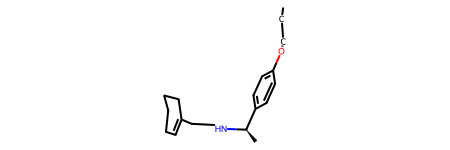

In [ ]:
from demo.ConfSeq import (
    get_ConfSeq_pair_from_mol,
    randomize_mol,
    replace_angle_brackets_with_line,
    get_mol_from_ConfSeq_pair,
    remove_degree_in_molblock
)

def convert_tdsmiles_to_mol(td_smiles):
    try:
        in_smiles = replace_angle_brackets_with_line(td_smiles)
        generated_mol = get_mol_from_ConfSeq_pair(in_smiles, td_smiles)
        generated_mol = Chem.MolFromMolBlock(remove_degree_in_molblock(Chem.MolToMolBlock(generated_mol)))
        if generated_mol is not None:
            return generated_mol
    except Exception as e:
        print(f"Failed to convert TD-SMILES to Mol: {e}")
    return None


mols = []
for i in range(200):
    try:
        confseq = PubChem_ID_ConfSeq_dic[str(topk_indices[i])]
        mols.append(convert_tdsmiles_to_mol(confseq))
    except:
        print('error')

mols[0]

In [38]:
PubChem_ID_ConfSeq_dic[str(topk_indices[0])]

'C C <111> | <-179> C <108> | <150> O <117> | <-149> c 1 c c c ( <61> [ C @ @ H ] ( C ) <79> N <110> | <-179> C <109> | <179> C <110> | <91> C 2 = C <13> C <-43> C <58> C <-43> C <-166> 2 ) c c 1'

In [41]:
len(mols)

96

In [20]:
def get_conf(para):
    in_smiles,TD_smiles = para
    try:
        conf = get_mol_from_ConfSeq_pair(in_smiles,TD_smiles,is_op = True)
        conf = Chem.MolFromMolBlock(remove_degree_in_molblock(Chem.MolToMolBlock(conf)))
    except:
        conf = ''
        #print('error')
    return conf

In [21]:
# import json

# # 假设你已经有一个字典 result_dict
# # result_dict = {'99975024': 'N # C <179> | / <-164> C ( = C <129> | ...', ...}

# output_json = './PubChem_ID_ConfSeq_dic.json'  # 替换为你的目标路径

# with open(output_json, 'w', encoding='utf-8') as f:
#     json.dump(result_dict, f, ensure_ascii=False, indent=2)
